<a href="https://colab.research.google.com/github/mke27/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%204/ECON3916_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 4: The Predictive Architecture


Phase 1: Causal Topology and Multicollinearity Forensics

Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

Omitted Confounder: Socioeconomic Status / systemic poverty

Socioeconomic Status (SES): fork 1: High_Deductible Insurance_Plan, fork 2: Inpatient_Admission_Rate

Regressing Admission on Insurance Type without controlling for this confounder yields a biased, mathematically contaminated predictive weight because Low-SES patients are more likely to be enrolled in high deductible plans and have higher inpatient admission rates due to lower baseline health.

Step 1.2: The Variance Inflation Factor (VIF) Audit

In [4]:
vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
X = vitals[features].dropna()

X_const = sm.add_constant(X)
vif_data = pd.DataFrame({
    "Feature": features,
    "VIF": [variance_inflation_factor(X_const.values, i + 1)
            for i in range(len(features))]
})

print("\n--- Initial VIF Matrix ---")
print(vif_data.to_string(index=False))


--- Initial VIF Matrix ---
     Feature       VIF
   Weight_kg 57.428058
   Height_cm 28.419446
         BMI 16.981232
 Systolic_BP  4.219406
Diastolic_BP  4.219820


In [5]:
print(f"Features exceeding VIF threshold of 10.0: Weight, Height, BMI")
# dropping BMI
features_reduced = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]
X_reduced = vitals[features_reduced].dropna()
X_reduced_const = sm.add_constant(X_reduced)

vif_reduced = pd.DataFrame({
    "Feature": features_reduced,
    "VIF": [variance_inflation_factor(X_reduced_const.values, i + 1)
            for i in range(len(features_reduced))]
})

print("\n--- VIF Matrix After Dropping BMI ---")
print(vif_reduced.to_string(index=False))

Features exceeding VIF threshold of 10.0: Weight, Height, BMI

--- VIF Matrix After Dropping BMI ---
     Feature      VIF
   Weight_kg 3.763969
   Height_cm 3.763812
 Systolic_BP 4.219406
Diastolic_BP 4.219820


Phase 2: Visual Forensics and The High-Cardinality Frontier

Step 2.1: The Architecture of Missingness

In [6]:
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")


--- Missingness Summary ---
Patient_ID                           0
High_Deductible_Insurance_Plan       0
Inpatient_Admission_Rate             0
Continuous_Heart_Rate             1214
Primary_Diagnosis_Code               0
Clinic_Capacity_Percentage           0
Time_of_Day_Index                    0
Procedure_Cost_USD                   0
dtype: int64


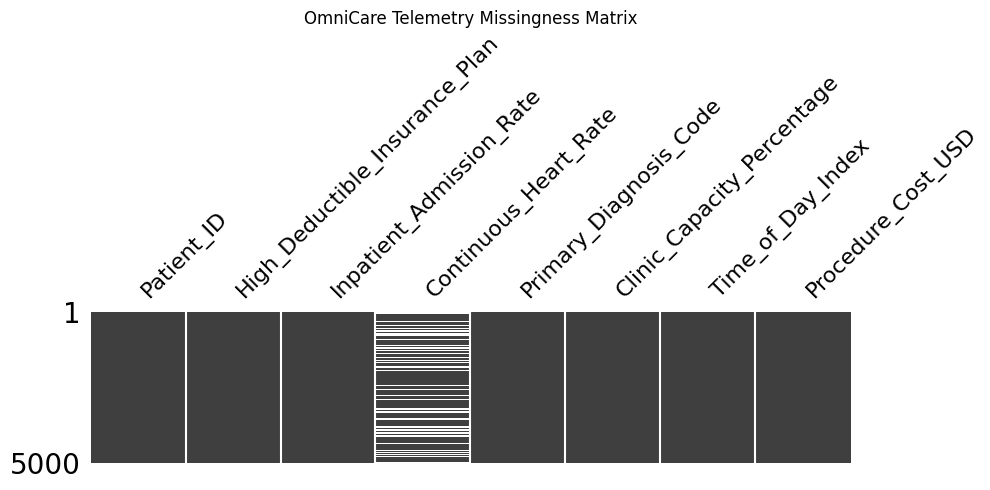

In [7]:
print("\n--- Missingness Summary ---")
print(telemetry.isnull().sum())

fig, ax = plt.subplots(figsize=(10, 5))
msno.matrix(telemetry, ax=ax, sparkline=False)
plt.title("OmniCare Telemetry Missingness Matrix")
plt.tight_layout()
plt.show()

If these gaps occur entirely because low-income patients systematically refuse to transmit telemetry due to the data-plan costs associated with continuous streaming, is this MCAR, MAR, or MNAR?

This is MNAR, missing not at random. Since low income patients cannot afford the mobile data plan required for telemetry, their heart rate data is missing because of their income. This means that there is a cause to the missingness and it is not random.

Mean imputation would destroy the integrity of the dataset because it would replace missing values with the average of observed values. This would be wrong because the observed values are primarily high income patients who can afford data plans, and using their data to replace low income patients' data would understate the risk of the low income patients.

Step 2.2: Escaping the Dummy Variable Trap

One-hot encoding 850 diagnosis codes creates 850 binary columns that always sum to exactly 1 for every row. But OLS also includes an intercept column, which is also a column of 1s. That means the intercept is a duplicate of the sum of all 850 dummy columns, making the design matrix linearly dependent.
OLS solves for coefficients using the formula β = (X'X)⁻¹X'y, which requires inverting the matrix X'X. A singular matrix has no inverse, so the formula doesn't work. To fix it, drop one dummy column so the columns are no longer the same. However, even with 849 remaining columns, the high amount of dimensions causes overfitting and memory issues. Therefore, target encoding (one column instead of 849) is the better solution.

Step 2.3: Target Encoding Implementation


In [8]:
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

telemetry["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    telemetry["Primary_Diagnosis_Code"],
    telemetry["Procedure_Cost_USD"]
)

print("\n--- First 5 rows: Target Encoded Diagnosis ---")
print(telemetry[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis",
                  "Procedure_Cost_USD"]].head())


--- First 5 rows: Target Encoded Diagnosis ---
  Primary_Diagnosis_Code  Target_Encoded_Diagnosis  Procedure_Cost_USD
0                J86.381               1707.697108             1635.84
1                M29.789               1792.303198             1355.77
2                E49.618               1730.334968             1189.19
3                E66.244               1725.060944             1250.93
4                J45.553               1801.821085             1986.34


Phase 3: Architecting the Prediction Engine

Step 3.1: OLS Optimization via Patsy Formulas

In [10]:
final_df = telemetry.merge(
    vitals[["Patient_ID", "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]],
    on="Patient_ID",
    how="inner"
)

final_df = final_df.dropna(subset=[
    "Procedure_Cost_USD", "Target_Encoded_Diagnosis",
    "Clinic_Capacity_Percentage", "Time_of_Day_Index",
    "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"
])

print(f"\nFinal analytical dataframe shape: {final_df.shape}")

formula = (
    "Procedure_Cost_USD ~ "
    "Target_Encoded_Diagnosis + "
    "Clinic_Capacity_Percentage + "
    "Time_of_Day_Index + "
    "Weight_kg + Height_cm + Systolic_BP + Diastolic_BP"
)

model = smf.ols(formula=formula, data=final_df).fit()
print("\n--- OLS Model Summary ---")
print(model.summary())


Final analytical dataframe shape: (5000, 13)

--- OLS Model Summary ---
                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        01:02:01   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

Step 3.2: Financial Loss Quantification (RMSE)


In [11]:
fitted_values = model.fittedvalues
actual_values = final_df["Procedure_Cost_USD"]

model_rmse = rmse(actual_values, fitted_values)
print(f"\n--- Root Mean Squared Error ---")
print(f"RMSE: ${model_rmse:,.2f}")


--- Root Mean Squared Error ---
RMSE: $334.80


The risks of deploying this dynamic pricing algorithm in a hospital are that the quoted prices are unreliable and would require overrides. Underpricing also means that the hospital is absorbing costs and suffering operating losses.

Step 3.3: Residual Diagnostics for Heteroscedasticity


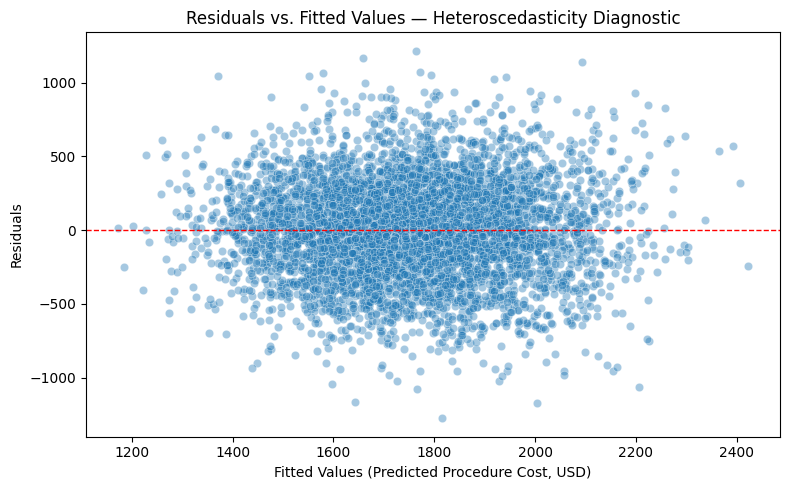

In [12]:
residuals = model.resid

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.4, ax=ax)
ax.axhline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Fitted Values (Predicted Procedure Cost, USD)")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs. Fitted Values — Heteroscedasticity Diagnostic")
plt.tight_layout()
plt.show()

My graph does not fan out. The spread of residuals looks very consistent and relatively homoscedastic. Thus, the OLS homoscedasticity assumption appears reasonably satisfied here.

Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

Task 4.1: Lagrange Multiplier Test for Heteroscedasticity


In [13]:
# Phase 4.1 — White's LM Test for Heteroscedasticity
from statsmodels.stats.diagnostic import het_white

# Extract residuals and the exogenous (X) matrix from the fitted model
residuals = model.resid
exog = model.model.exog  # the design matrix OLS used internally

# Run White's LM test
# Returns: LM statistic, LM p-value, F-statistic, F p-value
lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(residuals, exog)

print(f"LM Statistic:  {lm_stat:.4f}")
print(f"LM p-value:    {lm_pvalue:.4f}")
print(f"F-Statistic:   {f_stat:.4f}")
print(f"F p-value:     {f_pvalue:.4f}")

# Conclusion at alpha = 0.05
if lm_pvalue < 0.05:
    print("\nConclusion: The null hypothesis of homoscedasticity is REJECTED "
          "(p < 0.05) — statistically significant heteroscedasticity is present "
          "in the OLS residuals.")
else:
    print("\nConclusion: The null hypothesis of homoscedasticity is FAILED TO BE "
          "REJECTED (p >= 0.05) — no statistically significant heteroscedasticity "
          "detected at the alpha = 0.05 level.")

LM Statistic:  186.4677
LM p-value:    0.0000
F-Statistic:   5.4942
F p-value:     0.0000

Conclusion: The null hypothesis of homoscedasticity is REJECTED (p < 0.05) — statistically significant heteroscedasticity is present in the OLS residuals.
